# Bosques de Aislamiento (Isolation Forest)

### ¿Qué son los IForests?

* Los `Isolation Forests (iForest)` son un algoritmo de aprendizaje automático no supervisado que se usa principalmente para detección de anomalías (`outlier detection`).
* Es un modelo basado en árboles (similar en espíritu a Random Forest, pero con otro objetivo).
* La idea principal es que las anomalías son más fáciles de aislar que los puntos normales:
  - Los puntos anómalos suelen estar más alejados o en regiones de baja densidad.
  - Cuando construyes árboles que van dividiendo aleatoriamente el espacio, esos puntos `“raros”` se aíslan en menos pasos que los puntos normales.
    

* ***¿Cómo funciona?***
  - Se construyen muchos árboles de aislamiento (Isolation Trees, o iTrees).
  - Cada árbol divide el espacio aleatoriamente seleccionando.
  - Se mide la longitud del camino desde la raíz hasta el punto en el árbol.
  - `Anomalías` → se aíslan en pocos pasos → tienen caminos cortos.
  - `Normales` → necesitan más divisiones → tienen caminos largos.
  - Se combina la información de todos los árboles → se calcula un score de anomalía para cada punto.

* ***Ventajas***
  - Escala muy bien a grandes datasets.
  - No necesita supuestos de distribución (no asume normalidad).
  - Funciona bien en alta dimensión (donde otros métodos como k-means o distancias fallan).

### iForest vs DBSCAN vs PCA

| Método                                                                   | Idea principal                                                                                                     | Ventajas                                                                                                                                              | Desventajas                                                                                                                                                          | Cuándo usarlo                                                                                                            |
| ------------------------------------------------------------------------ | ------------------------------------------------------------------------------------------------------------------ | ----------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------ |
| **Isolation Forest (iForest)**                                           | Aíslas los datos construyendo árboles aleatorios → los outliers se aíslan en pocos pasos.                          | - Escala muy bien a datasets grandes.<br>- Funciona en **alta dimensión**.<br>- No requiere supuestos de distribución.<br>- Rápido.                   | - Tiene hiperparámetros que ajustar (`n_estimators`, `contamination`).<br>- Puede ser sensible a outliers extremos si los datos son muy escasos.                     | - Datos con **muchas variables (alta dimensión)**.<br>- Datasets grandes donde métodos basados en distancias son lentos. |
| **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) | Define clusters como regiones densas → los puntos que no pertenecen a un cluster son outliers.                     | - Encuentra clusters de forma **no lineal**.<br>- Detecta outliers naturalmente como ruido.<br>- No necesita número de clusters a priori.             | - Sensible a los parámetros `eps` (radio) y `min_samples`.<br>- Se degrada en **alta dimensión** (maldición de la dimensionalidad).                                  | - Datos en 2D o 3D con **clusters densos bien separados**.<br>- Para visualizar outliers fácilmente en gráficos.         |
| **PCA (Análisis de Componentes Principales)**                            | Reduce la dimensionalidad → los outliers aparecen como puntos con proyecciones “raras” en componentes principales. | - Útil para **visualizar datos en 2D/3D**.<br>- Permite ver qué dimensiones capturan más varianza.<br>- Puede resaltar outliers que afectan varianza. | - No es un detector de outliers en sí.<br>- Funciona mal si los outliers no afectan significativamente la varianza.<br>- Lineal (no captura relaciones no lineales). | - Cuando quieres **visualizar** anomalías.<br>- Preprocesamiento antes de aplicar otro detector (como iForest o DBSCAN). |


### Datos

* `from sklearn.ensemble import IsolationForest` librería para llamar los arboles de aislamiento.
* Parece que los datos ya están escalados.
* Se creó una matriz de 3 x78, ya que probaremos 3 tipos de grados contaminación.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

### Cargar datos
carros = np.loadtxt("carros_usados.csv", delimiter=",")
print(carros[0:5:1])

### Matriz de Ceros 3x78.
n, m = carros.shape
resultados = np.zeros((3, n))

[[0.0373 1.    ]
 [0.0801 0.9025]
 [0.1405 0.574 ]
 [0.1775 0.7396]
 [0.1627 0.6292]]


### Bosques Aleatorios.

* `plt.set_cmap("jet")` : Cambia el colormap (mapa de colores) por defecto que usará Matplotlib para las gráficas que representen valores con colores (ej. plt.imshow, plt.scatter con argumento c=..., plt.pcolormesh, etc.).
* `La documentación indica que contamination debe estar en (0, 0.5] o "auto".`

<Figure size 640x480 with 0 Axes>

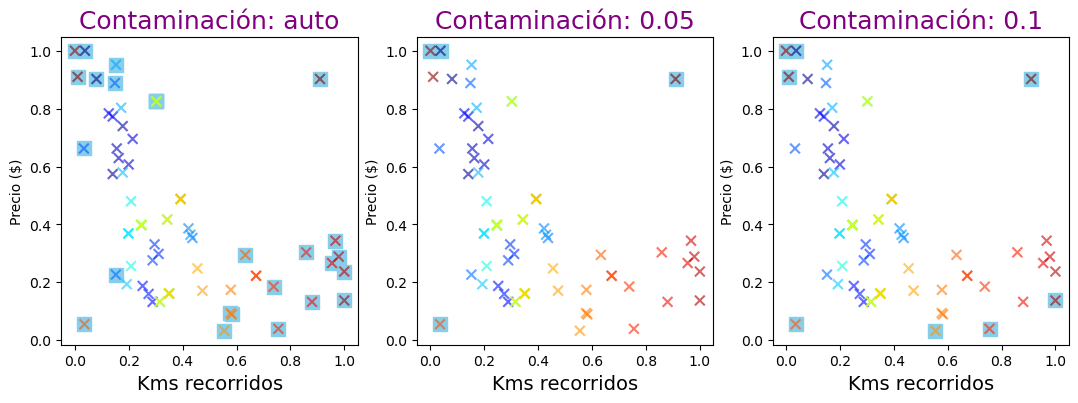

In [17]:
### Bosques de Aislamiento con diferente contaminación
c = ["auto", 0.05, 0.1]
for i, cont in enumerate(c):
    modelo = IsolationForest(contamination=cont).fit(carros)
    resultados[i] = modelo.predict(carros)
    
# Graficar datos anómalos 
plt.set_cmap("jet")
fig = plt.figure(figsize=(13, 4))

for i, cont in enumerate(c):    
    ax = fig.add_subplot(1, 3, i+1)
    ax.scatter(carros[resultados[i]==-1][:, 0], 
               carros[resultados[i]==-1][:, 1], 
               c="skyblue", marker="s", s=100)
    ax.scatter(carros[:, 0], 
               carros[:, 1], 
               c=range(n), marker="x",
               s=50, alpha=0.6)
    ax.set_title(f"Contaminación: {cont}", size=18, color="purple")
    ax.set_ylabel("Precio ($)", size=10)
    ax.set_xlabel("Kms recorridos", size=14)

plt.show()